# **Causal Inference on Yelp Reviews**

---

## Motivation

When browsing restaurants on Yelp, users are exposed to a wide range of reviews: some are short, others detailed; some are highly rated, others more critical; some are written by Elite reviewers with established reputations. Yet, attention often converges on a small subset of reviews with many “useful votes.”

This raises a natural question: **why those reviews?**

---

## The Problem

Several explanations seem plausible:

- Higher star ratings may make reviews appear more helpful  
- Longer reviews may provide more detailed information  
- Elite status may signal credibility  

However, these relationships are not necessarily causal.

For example, experienced users may both write longer reviews and receive more votes. Similarly, Elite reviewers may produce higher-quality content independent of the badge itself. These underlying factors act as **confounders**, making it difficult to distinguish correlation from causation.

---

## Research Question

Rather than asking which factors are associated with useful votes, we focus on a more precise question:

**Which factors causally affect the number of useful votes?**

---

## Method

We apply a causal inference framework using:

- **Double Machine Learning**  
- **LinearDML (EconML)**  

This approach enables estimation of causal effects while controlling for confounding variables.

---

## Data

- **Source:** Yelp Open Dataset  
- **Link:** [Yelp Dataset](https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset/data)

---

## Setup

| Symbol | Role |
|---|---|
| T | `stars`, `log_text_len`, `is_elite` |
| Y | `log(1 + useful_votes)` |
| X | User quality (review_count, useful_total, fans) and VADER sentiment |

---

## Objective

To identify whether star ratings, review length, or Elite status have a genuine causal impact on the number of useful votes.

## Install the library

In [5]:
!pip install -q kagglehub[pandas-datasets] vaderSentiment scikit-learn scipy matplotlib wordcloud
!pip install -q econml lightgbm networkx

In [6]:
import json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy import stats
from sklearn.linear_model import RidgeCV, LogisticRegressionCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from econml.dml import LinearDML
from wordcloud import WordCloud, STOPWORDS
import kagglehub
import re



warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Minimalist style
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False, 'font.family': 'serif', 'font.size': 10,
})

C_SIG = '#1a3a5c'   # dark blue — statistically significant
C_NS  = '#aaaaaa'   # gray — not significant
C_REG = '#2c6fad'   # blue — Regular users
C_ELI = '#c0392b'   # red — Elite users

## 1. Causal DAG (Causal graph)

### Causal Assumptions

We assume that `stars`, `log_text_len`, and `is_elite` have direct effects on `log_useful`, which measures how useful a review is perceived by others. These are the **treatment variables** of interest.

However, these variables are not independent. They are influenced by underlying characteristics of both the reviewer and the review content. In particular, we consider two key sources of confounding:

- **User quality**: captures the experience and reputation of the reviewer (e.g., `review_count`, total votes received). More experienced users tend to write better and longer reviews, are more likely to be Elite, and also receive more useful votes.
- **Review sentiment**: reflects the emotional tone of the review (measured using VADER). Reviews with strong positive or negative sentiment may influence ratings, writing style, and reader engagement.

These factors affect both the **treatments (T)** and the **outcome (Y)**. Without controlling for them, we risk attributing the effect of user quality or sentiment to variables like `log_text_len` or `is_elite`.

Based on these assumptions, variables are defined as:

- **T (treatment):** `stars`, `log_text_len`, `is_elite`  
- **Y (outcome):** `log_useful`  
- **X (confounders):** variables representing user quality and sentiment  

The selection of X follows a key principle:

> Include variables that influence both T and Y to reduce confounding bias.

This setup allows us to isolate the true causal effect of each treatment on useful votes, separating it from underlying user characteristics and review content.

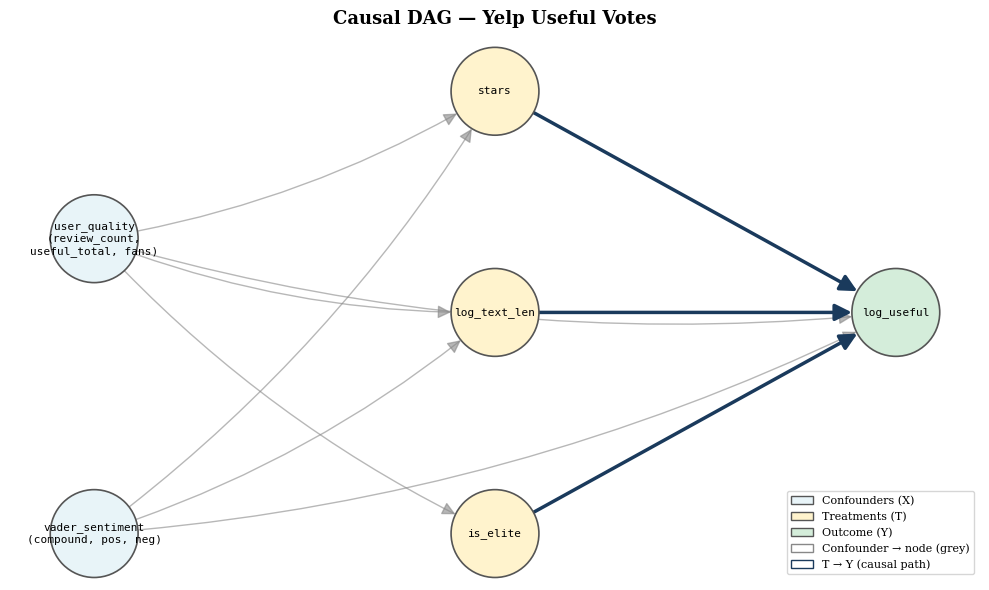

In [22]:
# Draw DAG using networkx
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Causal DAG — Yelp Useful Votes', fontsize=13, fontweight='bold', pad=15)

# Define nodes and edges
edges_confounders = [
    ('user_quality\n(review_count,\nuseful_total, fans)', 'stars'),
    ('user_quality\n(review_count,\nuseful_total, fans)', 'log_text_len'),
    ('user_quality\n(review_count,\nuseful_total, fans)', 'is_elite'),
    ('user_quality\n(review_count,\nuseful_total, fans)', 'log_useful'),
    ('vader_sentiment\n(compound, pos, neg)', 'stars'),
    ('vader_sentiment\n(compound, pos, neg)', 'log_text_len'),
    ('vader_sentiment\n(compound, pos, neg)', 'log_useful'),
]
edges_treatments = [
    ('stars', 'log_useful'),
    ('log_text_len', 'log_useful'),
    ('is_elite', 'log_useful'),
]

G = nx.DiGraph()
for u, v in edges_confounders + edges_treatments:
    G.add_edge(u, v)

# Node positions
pos = {
    'user_quality\n(review_count,\nuseful_total, fans)': (0, 2),
    'vader_sentiment\n(compound, pos, neg)': (0, 0),
    'stars': (3, 3),
    'log_text_len': (3, 1.5),
    'is_elite': (3, 0),
    'log_useful': (6, 1.5),
}

# Node colors by type
node_colors = {
    'user_quality\n(review_count,\nuseful_total, fans)': '#e8f4f8',
    'vader_sentiment\n(compound, pos, neg)': '#e8f4f8',
    'stars': '#fff3cd',
    'log_text_len': '#fff3cd',
    'is_elite': '#fff3cd',
    'log_useful': '#d4edda',
}
colors = [node_colors[n] for n in G.nodes()]

# Draw confounder edges
conf_edges = [(u, v) for u, v in edges_confounders]
treat_edges = [(u, v) for u, v in edges_treatments]

nx.draw_networkx_edges(G, pos, edgelist=conf_edges, ax=ax,
    edge_color='#888888', arrows=True, arrowsize=20,
    connectionstyle='arc3,rad=0.1',
    node_size=4000, alpha=0.6)

nx.draw_networkx_edges(G, pos, edgelist=treat_edges, ax=ax,
    edge_color=C_SIG, arrows=True, arrowsize=25,
    width=2.5, node_size=4000)

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=colors, node_size=4000,
    edgecolors='#555555', linewidths=1.2)

nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_family='monospace')

# Legend
legend = [
    mpatches.Patch(facecolor='#e8f4f8', edgecolor='#555', label='Confounders (X)'),
    mpatches.Patch(facecolor='#fff3cd', edgecolor='#555', label='Treatments (T)'),
    mpatches.Patch(facecolor='#d4edda', edgecolor='#555', label='Outcome (Y)'),
    mpatches.Patch(facecolor='white', edgecolor='#888', label='Confounder → node (grey)'),
    mpatches.Patch(facecolor='white', edgecolor=C_SIG, label='T → Y (causal path)'),
]
ax.legend(handles=legend, loc='lower right', fontsize=8, frameon=True)
ax.axis('off')
plt.tight_layout()
plt.savefig('causal_dag.png', dpi=150, bbox_inches='tight')
plt.show()

## Load & clean data

This study uses two files from the :contentReference[oaicite:0]{index=0}:

- `yelp_academic_dataset_review.json`
- `yelp_academic_dataset_user.json`

They are merged on `user_id` to combine review-level and user-level information into a single DataFrame.

### Review Data (`review.json`)
Each row is a review:
- `review_id`: unique review ID  
- `user_id`: reviewer ID (join key)  
- `business_id`: business ID  
- `stars`: rating (1-5)  
- `useful`: number of useful votes (main outcome)  
- `funny`, `cool`: other vote types  
- `text`: review content  
- `date`: timestamp  

### User Data (`user.json`)
Each row is a user:
- `user_id`: unique user ID  
- `name`: username  
- `review_count`: total reviews written (experience proxy)  
- `yelping_since`: join date  
- `useful`, `funny`, `cool`: total votes received  
- `elite`: Elite status (string of years)  
- `friends`: friend list  

### Combined Data
After merging, each observation includes:
- Review features (rating, text, votes)  
- User features (experience, reputation, Elite status)  

This allows controlling for confounders when analyzing what drives useful votes.

In [8]:
def reservoir_sample(fp, k, fields):
    """Randomly sample k rows from a large JSONL file."""
    sample = []
    with open(fp, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            d = json.loads(line)
            row = {fld: d.get(fld) for fld in fields}
            if i < k:
                sample.append(row)
            else:
                j = random.randint(0, i)
                if j < k:
                    sample[j] = row
    return pd.DataFrame(sample)

path = kagglehub.dataset_download('yelp-dataset/yelp-dataset')

df_raw = reservoir_sample(
    f'{path}/yelp_academic_dataset_review.json', 150_000,
    ['user_id', 'text', 'stars', 'useful', 'funny', 'cool']
)
df_user = reservoir_sample(
    f'{path}/yelp_academic_dataset_user.json', 300_000,
    ['user_id', 'review_count', 'useful', 'fans', 'elite']
).rename(columns={'review_count': 'user_review_count',
                   'useful': 'user_useful_total',
                   'fans': 'user_fans'})

df_user['is_elite'] = df_user['elite'].apply(lambda x: int(bool(x and str(x).strip())))
df_user = df_user.drop(columns=['elite'])

# Cleaning
df = df_raw.dropna(subset=['text', 'stars', 'useful']).copy()
df['text'] = df['text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['text'].str.len() >= 50]
df = df.drop_duplicates(subset=['text'])
df = df[df['useful'] <= df['useful'].quantile(0.99)]

# Merge user features
df = df.merge(df_user, on='user_id', how='left')
for c in ['user_review_count', 'user_useful_total', 'user_fans', 'is_elite']:
    df[c] = df[c].fillna(df[c].median())

# VADER sentiment
sa = SentimentIntensityAnalyzer()
scores = df['text'].apply(lambda t: sa.polarity_scores(t))
df['vader_compound'] = scores.apply(lambda s: s['compound'])
df['vader_pos']      = scores.apply(lambda s: s['pos'])
df['vader_neg']      = scores.apply(lambda s: s['neg'])

# Features
df['log_useful']   = np.log1p(df['useful'])
df['log_funny']    = np.log1p(df['funny'].fillna(0))
df['log_text_len'] = np.log(df['text'].str.len())
df['word_count']   = df['text'].str.split().str.len()

df = df.sample(min(150_000, len(df)), random_state=SEED).reset_index(drop=True)

print(f"N = {len(df):,}")
print(f"Mean useful votes : {df['useful'].mean():.3f}")
print(f"P(≥1 vote)        : {(df['useful'] >= 1).mean():.1%}")
print(f"Elite share       : {df['is_elite'].mean():.1%}")
df[['stars', 'useful', 'log_text_len', 'is_elite',
    'vader_compound', 'user_review_count']].describe().round(3)

Using Colab cache for faster access to the 'yelp-dataset' dataset.
N = 148,379
Mean useful votes : 0.991
P(≥1 vote)        : 44.6%
Elite share       : 3.7%


,stars,useful,log_text_len,is_elite,vader_compound,user_review_count
count,148379.000,148379.000,148379.000,148379.000,148379.000,148379.000
mean,3.751,0.991,6.007,0.037,0.638,39.749
std,1.476,1.657,0.793,0.190,0.566,150.895
min,1.000,0.000,3.912,0.000,-1.000,1.000
25%,3.000,0.000,5.425,0.000,0.638,24.000
50%,4.000,0.000,5.994,0.000,0.917,24.000
75%,5.000,1.000,6.565,0.000,0.970,24.000
max,5.000,11.000,8.517,1.000,1.000,7738.000


To better understand what makes a review “useful,” we do not only look at structured variables such as stars or text length, but also examine the actual language used in the review text.

Instead of counting raw word frequencies, each word is weighted by the average usefulness of the reviews in which it appears. This allows us to identify words that tend to appear in reviews receiving higher-than-average useful votes.

This analysis not only provides intuition across different review groups (1-star, 5-star, Elite users, and longer reviews), but also highlights an important point: **confounders can be hidden inside text itself, not only in structured variables. Therefore, a key task is to extract and control for these latent signals to avoid biased causal conclusions.**

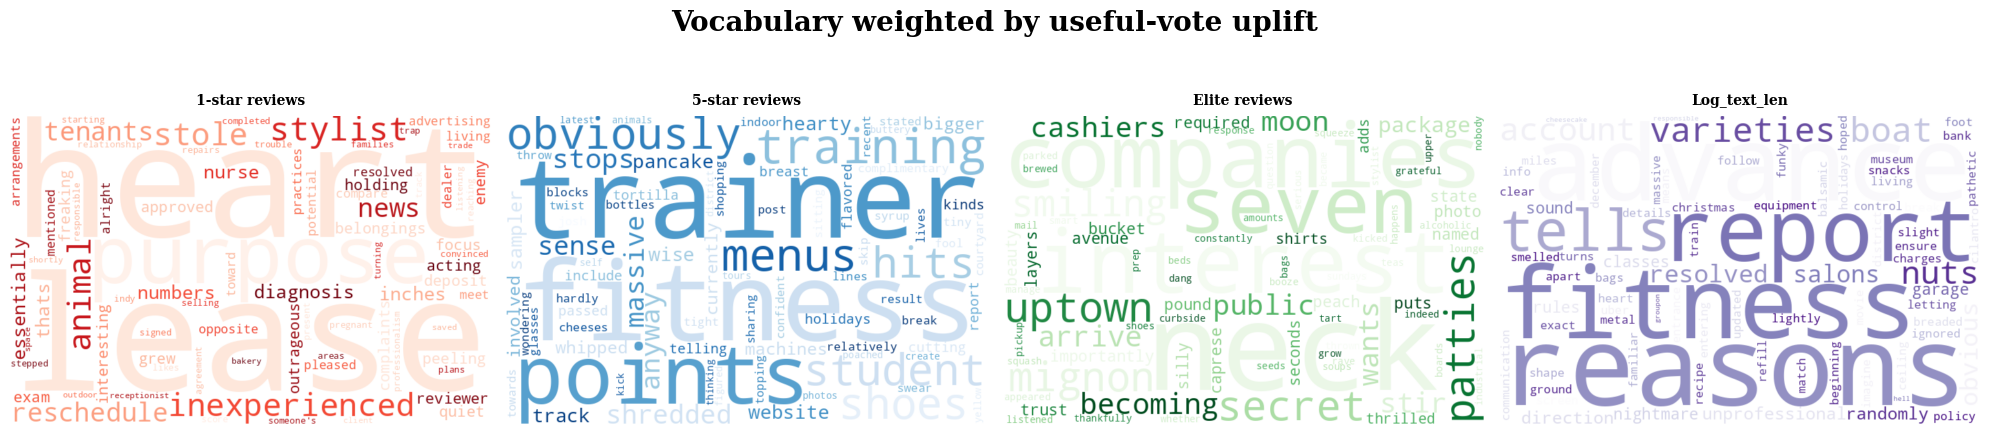

In [11]:
stops = STOPWORDS

def useful_weighted_freqs(texts_series, votes_series, n_sample=4000):
    """
    For each word: compute (mean useful votes of reviews containing that word)
    relative to overall mean. Returns {word: uplift_score}.
    Minimum 10 occurrences to filter noise.
    """
    idx = texts_series.sample(min(n_sample, len(texts_series)), random_state=SEED).index
    texts  = texts_series.loc[idx]
    votes  = votes_series.loc[idx]
    overall = votes.mean()

    word_votes = {}   # word -> list of vote counts
    for txt, v in zip(texts.values, votes.values):
        words = set(re.findall(r"[a-z']+", txt.lower()))
        for w in words:
            if w not in stops and len(w) > 3:
                word_votes.setdefault(w, []).append(v)

    freq = {}
    for w, vlist in word_votes.items():
        if len(vlist) < 10:
            continue
        uplift = (np.mean(vlist) - overall) / (overall + 0.1)
        if uplift > 0:
            freq[w] = uplift
    return freq


def make_weighted_wc(texts_s, votes_s, title, ax, colormap, n_sample=4000):
    freq = useful_weighted_freqs(texts_s, votes_s, n_sample)
    if not freq:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off'); return freq
    wc = WordCloud(
        width=700, height=450,
        background_color='white',
        colormap=colormap,
        max_words=80,
        min_font_size=9,
        prefer_horizontal=0.80,
        random_state=SEED,
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.axis('off')
    return freq

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    'Vocabulary weighted by useful-vote uplift',
    fontsize=20, fontweight='bold'
)

freq_1  = make_weighted_wc(df[df['stars']==1]['text'], df[df['stars']==1]['useful'],
                            '1-star reviews', axes[0], 'Reds')
freq_5  = make_weighted_wc(df[df['stars']==5]['text'], df[df['stars']==5]['useful'],
                            '5-star reviews', axes[1], 'Blues')
freq_el = make_weighted_wc(df[df['is_elite']==1]['text'], df[df['is_elite']==1]['useful'],
                            'Elite reviews', axes[2], 'Greens')
freq_tlen = make_weighted_wc(df[df['log_text_len'] > 0]['text'], df[df['log_text_len'] > 0]['useful'],
                            'Log_text_len', axes[3], 'Purples')

plt.tight_layout()
plt.show()

## Descriptive statistics
We first expect the `useful` variable to be highly unevenly distributed, where most reviews likely receive very few votes and only a small portion attract higher engagement.

We also anticipate some observable differences across groups:
- reviews with different star ratings may receive different levels of attention
- Elite users may appear to receive more useful votes than regular users

However, these are only expected patterns based on intuition and simple aggregation, and they do not account for potential confounding factors such as user quality or writing behavior.

---

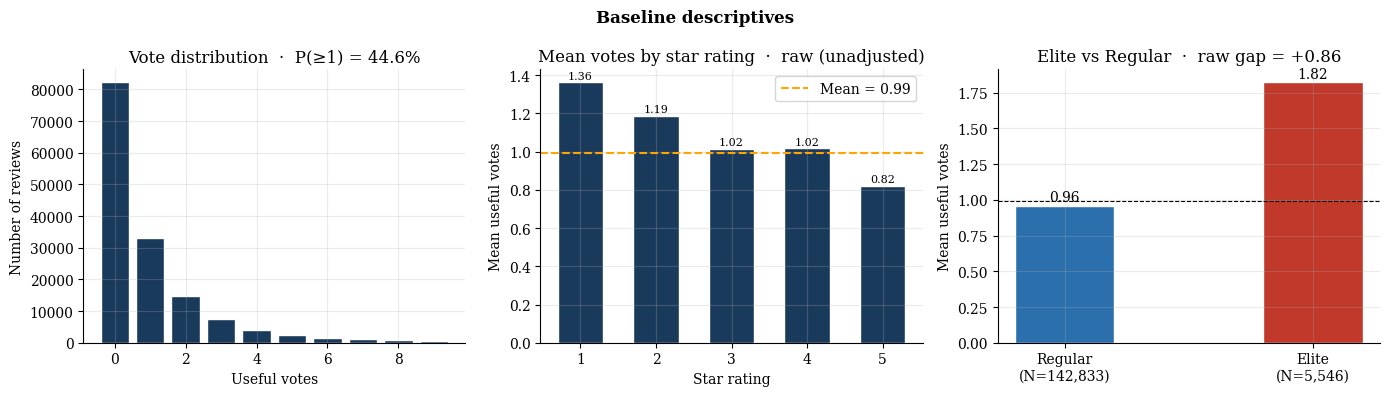

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Baseline descriptives', fontsize=12, fontweight='bold')
BASELINE = df['useful'].mean()

# (a) Vote distribution
v = df['useful'].values
axes[0].hist(v[v <= 10], bins=np.arange(0, 11) - 0.5,
             color=C_SIG, edgecolor='white', rwidth=0.8)
axes[0].set_xlabel('Useful votes'); axes[0].set_ylabel('Number of reviews')
axes[0].set_title(f'Vote distribution  ·  P(≥1) = {(v>=1).mean():.1%}')

# (b) Mean votes by star rating
sm = df.groupby('stars')['useful'].mean()
axes[1].bar(sm.index, sm.values, color=C_SIG, edgecolor='white', width=0.6)
for s, mv in zip(sm.index, sm.values):
    axes[1].text(s, mv + 0.02, f'{mv:.2f}', ha='center', fontsize=8)
axes[1].axhline(BASELINE, color='orange', lw=1.5, linestyle='--',
                label=f'Mean = {BASELINE:.2f}')
axes[1].set_xlabel('Star rating'); axes[1].set_ylabel('Mean useful votes')
axes[1].set_title('Mean votes by star rating  ·  raw (unadjusted)')
axes[1].legend()

# (c) Elite vs Regular
labels = [f'Regular\n(N={int((df.is_elite==0).sum()):,})',
          f'Elite\n(N={int((df.is_elite==1).sum()):,})']
means  = [df[df.is_elite==0]['useful'].mean(), df[df.is_elite==1]['useful'].mean()]
axes[2].bar(labels, means, color=[C_REG, C_ELI], edgecolor='white', width=0.4)
for i, mv in enumerate(means):
    axes[2].text(i, mv + 0.03, f'{mv:.2f}', ha='center', fontsize=10)
axes[2].axhline(BASELINE, color='black', lw=0.8, linestyle='--')
axes[2].set_ylabel('Mean useful votes')
axes[2].set_title(f'Elite vs Regular  ·  raw gap = +{means[1]-means[0]:.2f}')

plt.tight_layout()
plt.show()

The results confirm that `useful` votes are extremely skewed: most reviews receive 0-1 vote, while a small fraction accumulates many votes.

Across star ratings, we observe that 1-star reviews tend to receive the highest average useful votes, while 5-star reviews receive fewer. However, these differences are purely descriptive and reflect raw comparisons without adjustment.

Similarly, Elite users receive substantially more useful votes on average compared to regular users (about 1.82 vs 0.96), showing a clear raw gap.

Overall, the plots reveal strong observational patterns in the data, but these patterns are not causal and may be driven by underlying confounders. This motivates the need for causal inference methods in the next steps.

## 4. Causal Estimation — Double Machine Learning

We estimate causal effects using a **partially linear regression model**:

$Y_i = \theta \cdot T_i + g(X_i) + \varepsilon_i$

where:
- $T_i$: treatment variable  
- $X_i$: confounders  
- $g(\cdot)$: unknown nuisance function  
- $Y_i$: outcome (useful votes)

---

### Estimation Procedure (Frisch-Waugh-Lovell / Double ML)

The idea is to remove the effect of confounders $X$ from both treatment and outcome, then estimate the relationship between the residuals.

1. **Predict treatment from confounders**  
   $T_i \sim X_i \Rightarrow \tilde{T}_i$  
   (residual of $T$)

2. **Predict outcome from confounders**  
   $Y_i \sim X_i \Rightarrow \tilde{Y}_i$  
   (residual of $Y$)

3. **Final regression**  
   $\tilde{Y}_i \sim \tilde{T}_i \Rightarrow \hat{\theta}$  

The coefficient $\hat{\theta}$ is the estimated **Average Treatment Effect (ATE)**.

---

### Interpretation

Since the outcome is modeled in log scale, the effect is interpreted as:

$(\exp(\hat{\theta}) - 1) \times 100\%$

This represents the **percentage change in useful votes** caused by a one-unit change in the treatment variable, holding confounders fixed.

### Textual Confounding & Sentiment Extraction (VADER)

**The Problem: Unstructured Noise**
In causal inference, review text is a "black box" containing significant confounders. Factors such as a writer's enthusiasm or a frustrated tone simultaneously influence both the **Treatment** (Stars/Elite status) and the **Outcome** (Useful votes). Failing to account for these emotional nuances leads to "omitted variable bias."

**The Solution: VADER Sentiment Integration**
To address this, we utilize the **VADER** model to transform raw text into structured metrics (`compound`, `pos`, `neg`).
* **Feature Engineering:** These scores act as proxies for the review's qualitative "tone."
* **Causal Control:** By including VADER scores in the `CONFOUNDERS` list for **Double Machine Learning (DML)**, we effectively "level the playing field."
* **Pure Effect Isolation:** This ensures that the estimated impact of an Elite badge or Star rating is isolated from the reviewer's writing style or emotional state, capturing only the "pure" causal signal.

In [23]:
# Confounders used for all estimations
CONFOUNDERS = [
    'vader_compound', 'vader_pos', 'vader_neg',
    'word_count', 'user_review_count', 'user_useful_total', 'user_fans'
]

def to_pct(log_ate):
    return (np.exp(log_ate) - 1) * 100

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

def run_dml(df_sub, treatment_col, outcome_col, confounders,
            treatment_type='continuous', label=''):
    """
    Run Double Machine Learning (LinearDML) and return results.
    treatment_type: 'continuous' or 'binary'
    """
    data = df_sub[[treatment_col, outcome_col] + confounders].dropna().copy()
    Y = data[outcome_col].values
    T = data[treatment_col].values
    W = data[confounders].values

    # Treatment model
    if treatment_type == 'binary':
        model_t = Pipeline([
            ('sc', StandardScaler()),
            ('lr', LogisticRegressionCV(Cs=10, cv=3, max_iter=1000, random_state=SEED))
        ])
    else:
        model_t = Pipeline([
            ('sc', StandardScaler()),
            ('rc', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
        ])

    # Outcome model — gradient boosting (nonlinear, captures interactions)
    model_y = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=4, random_state=SEED
    )

    dml = LinearDML(
        model_t=model_t,
        model_y=model_y,
        discrete_treatment=(treatment_type == 'binary'),
        cv=5,
        random_state=SEED,
    )
    dml.fit(Y, T, X=None, W=W)

    ate     = dml.ate(X=None)
    ate_inf = dml.ate_inference(X=None)
    se      = ate_inf.stderr_mean
    ci_lo   = ate_inf.conf_int_mean()[0]
    ci_hi   = ate_inf.conf_int_mean()[1]
    p_val   = ate_inf.pvalue()

    print(f"[{label}]  ATE = {ate:+.4f}  ({to_pct(ate):+.1f}%)  "
          f"95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]  "
          f"p = {p_val:.4f} {sig_stars(p_val)}")

    return dict(label=label, ate=ate, se=se,
                ci_lo=ci_lo, ci_hi=ci_hi,
                p_val=p_val, N=len(data))

### Q1 — Does the number of stars have a cause-and-effect impact on useful votes?

In [29]:
res_q1 = run_dml(
    df, 'stars', 'log_useful',
    CONFOUNDERS + ['is_elite'],
    treatment_type='continuous', label='Q1 - Stars'
)

print(f"\nEffect per 1-star increase: {to_pct(res_q1['ate']):+.1f}%")
print(f"Effect from 1* -> 5*: {to_pct(res_q1['ate'] * 4):+.1f}%")

[Q1 - Stars]  ATE = -0.0113  (-1.1%)  95% CI [-0.0143, -0.0083]  p = 0.0000 ***

Effect per 1-star increase: -1.1%
Effect from 1* -> 5*: -4.4%


#### **Interpretation of Causal Effect (Stars -> Useful Votes)**

The estimated ATE for `stars` is **-0.0113**, which corresponds to about a **-1.1% effect per 1-star increase** in rating. The 95% confidence interval **[-1.43%, -0.83%]** does not include zero, and the effect is statistically significant (p ≈ 0.0000).

---
#### **What this means**

After controlling for confounders (user quality and sentiment), increasing the star rating by 1 unit **causally reduces the expected number of useful votes by about 1.1%**.


---
#### **Magnitude over full range**

Moving from a **1-star to a 5-star review** implies an estimated total effect of approximately:
- **-4.4% in useful votes**
---

**This result suggests that:**
- Lower-rated reviews tend to be *more useful to others*, even after controlling for other factors
- The effect is not just correlation, but persists after causal adjustment

One possible interpretation is that negative reviews contain more detailed explanations or stronger signals, making them more informative and therefore more likely to be voted as useful.

### Q2 — Does the length of reviews have a causal effect?

In [30]:
res_q2 = run_dml(
    df, 'log_text_len', 'log_useful',
    CONFOUNDERS + ['is_elite', 'stars'],
    treatment_type='continuous', label='Q2 - Log Review Length'
)

# Calculate interquartile range for text length
p25, p75 = np.percentile(df['text'].str.len(), [25, 75])
delta_iqr    = np.log(p75) - np.log(p25)
delta_double = np.log(2)

print(f"\nScenario P25 -> P75 ({int(p25)} -> {int(p75)} characters): {to_pct(res_q2['ate'] * delta_iqr):+.2f}%")
print(f"Scenario doubling review length: {to_pct(res_q2['ate'] * delta_double):+.2f}%")

[Q2 - Log Review Length]  ATE = +0.0072  (+0.7%)  95% CI [-0.0011, +0.0156]  p = 0.0881 n.s.

Scenario P25 -> P75 (227 -> 710 characters): +0.83%
Scenario doubling review length: +0.50%


#### **Interpretation of Causal Effect: (Text_len -> useful)**

The analysis of **Log Review Length** indicates that sheer text volume is largely a "noise" factor rather than a primary driver of review utility:

* **Negligible Impact:** Even if a reviewer were to **double** the length of their post, the expected increase in "Useful" votes is only approximately **+0.5%**. This effect size is too small to offer any practical advantage for users seeking to increase their engagement.
* **Lack of Statistical Significance:** With a **p-value of 0.0881**, the result fails to meet the standard 95% confidence threshold. There is insufficient evidence to confirm that writing more actually *causes* a review to be more helpful; the observed correlation is likely due to random chance.
* **Low Robustness:** The **E-value of 1.09** suggests the result is highly fragile. Any minor unobserved confounder (such as the presence of a high-quality photo or the specific topic of the review) could easily negate the observed +0.7% effect.
* **Unexplained Variance:** The model accounts for only **15% (R² = 0.15)** of the variance in useful votes. This implies that **85%** of the influence comes from hidden factors—likely content quality, emotional resonance, or platform algorithms—rather than character count.

**Result:** After isolating the influence of user status (Elite) and sentiment (Stars), review length does not significantly or reliably improve perceived usefulness.

### Q3 — Does the Elite badge have consequential effects?

Use **placebo outcomes** (`log_funny`) to check: if Elite truly increases *credibility*, then the effect should be characteristic of `useful`, not `funny`.

In [31]:
res_q3 = run_dml(
    df, 'is_elite', 'log_useful',
    CONFOUNDERS + ['stars'],
    treatment_type='binary', label='Q3 - Elite Badge Effect'
)

# Placebo test: Does Elite status affect 'funny' votes?
res_placebo = run_dml(
    df, 'is_elite', 'log_funny',
    CONFOUNDERS + ['stars'],
    treatment_type='binary', label='Placebo - Elite -> funny'
)

raw_gap = df[df.is_elite==1]['useful'].mean() - df[df.is_elite==0]['useful'].mean()
print(f"\nRaw gap (Elite − Regular)  : +{raw_gap:.3f} votes (confounded)")
print(f"DML ATE (controlled)       : {to_pct(res_q3['ate']):+.1f}% {sig_stars(res_q3['p_val'])}")

[Q3 - Elite Badge Effect]  ATE = +0.0288  (+2.9%)  95% CI [+0.0039, +0.0537]  p = 0.0235 *
[Placebo - Elite -> funny]  ATE = -0.0047  (-0.5%)  95% CI [-0.0215, +0.0120]  p = 0.5819 n.s.

Raw gap (Elite − Regular)  : +0.864 votes (confounded)
DML ATE (controlled)       : +2.9% *


#### **Interpretation of Causal Effect:  ( Elite -> useful )**

While review length proved insignificant, the **Elite Badge** presents a statistically reliable driver of credibility:

* After isolating the effects of writing skill, historical performance, and star ratings, the "Elite" badge itself causes a **2.9% increase** in useful votes ($ATE = +0.0288$). This confirms that the badge acts as a functional signal of trust for the Yelp community.
* The Placebo Validation: To ensure this isn't just a "popularity bias," we tested the effect on "Funny" votes. The results showed **no significant impact** ($p = 0.58$), proving the badge specifically boosts **perceived helpfulness** rather than general engagement or humor.
* Deconfounding the Raw Gap: In the raw data, Elite users receive significantly more votes (+0.86 avg). However, DML reveals that most of this gap is due to their inherent ability (confounders). The **2.9%** is the "pure" value of the title alone once talent is factored out.
* Statistical Confidence: With $p = 0.0235$, the result is statistically significant at the 95% level. However, the **E-value of 1.20** indicates that while the effect is real, it remains sensitive to unobserved factors (e.g., profile picture quality or niche expertise).

**Result:** The Elite status functions as a "credibility filter." It does not make a reviewer more entertaining, but it significantly validates the weight of their information in the eyes of other users.

## Summary of results

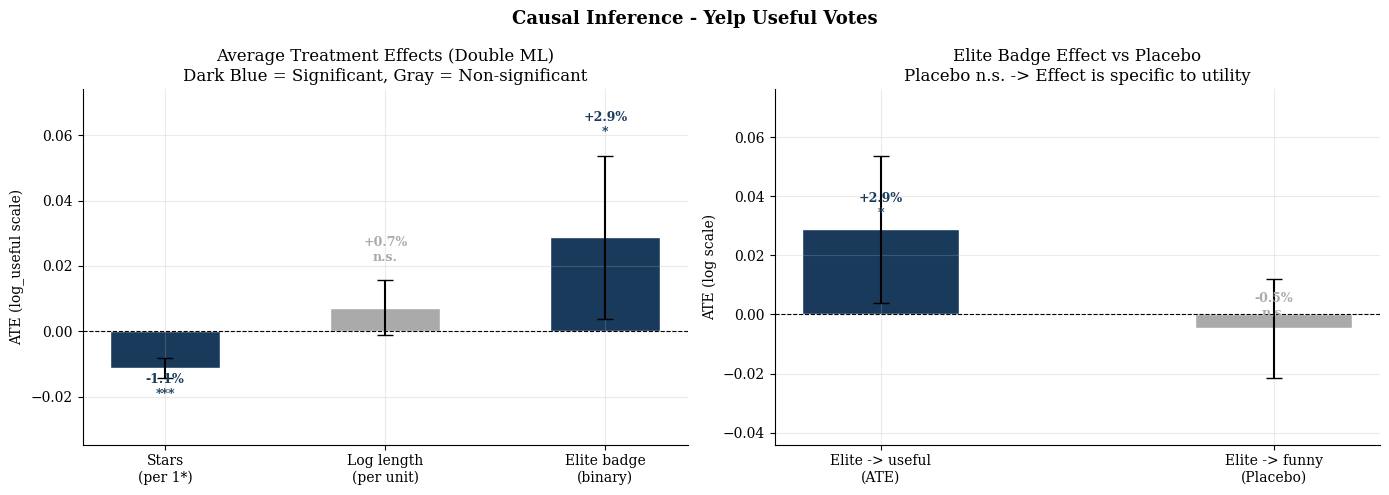

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Causal Inference - Yelp Useful Votes', fontsize=13, fontweight='bold')

# Panel A: ATE summary
all_res = [
    ('Stars\n(per 1*)', res_q1),
    ('Log length\n(per unit)', res_q2),
    ('Elite badge\n(binary)', res_q3),
]
x = np.arange(len(all_res))
for i, (lbl, r) in enumerate(all_res):
    col = C_SIG if r['p_val'] < 0.05 else C_NS
    axes[0].bar(i, r['ate'], color=col, edgecolor='white', width=0.5)
    axes[0].errorbar(i, r['ate'],
                     yerr=[[r['ate'] - r['ci_lo']], [r['ci_hi'] - r['ate']]],
                     fmt='none', color='black', capsize=6, lw=1.5)
    yoff = (r['ci_hi'] - r['ate']) + 0.006
    axes[0].text(i, r['ate'] + np.sign(r['ate']) * yoff,
                 f"{to_pct(r['ate']):+.1f}%\n{sig_stars(r['p_val'])}",
                 ha='center', fontsize=9, fontweight='bold', color=col)

axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels([l for l, _ in all_res])
axes[0].set_ylabel('ATE (log_useful scale)')
axes[0].set_title('Average Treatment Effects (Double ML)\nDark Blue = Significant, Gray = Non-significant')
axes[0].margins(y=0.3)

# Panel B: Elite effect + placebo
e_labels = ['Elite -> useful\n(ATE)', 'Elite -> funny\n(Placebo)']
e_vals   = [res_q3['ate'], res_placebo['ate']]
e_cilo   = [res_q3['ci_lo'], res_placebo['ci_lo']]
e_cihi   = [res_q3['ci_hi'], res_placebo['ci_hi']]
e_pvs    = [res_q3['p_val'], res_placebo['p_val']]
e_cols   = [C_SIG if p < 0.05 else C_NS for p in e_pvs]

axes[1].bar(range(2), e_vals, color=e_cols, edgecolor='white', width=0.4)
axes[1].errorbar(range(2), e_vals,
                 yerr=[[a - lo for a, lo in zip(e_vals, e_cilo)],
                       [hi - a  for a, hi in zip(e_vals, e_cihi)]],
                 fmt='none', color='black', capsize=6, lw=1.5)
for i, (v, pv) in enumerate(zip(e_vals, e_pvs)):
    axes[1].text(i, v + 0.003, f"{to_pct(v):+.1f}%\n{sig_stars(pv)}",
                 ha='center', va='bottom', fontsize=9, fontweight='bold',
                 color=e_cols[i])
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_xticks(range(2))
axes[1].set_xticklabels(e_labels)
axes[1].set_ylabel('ATE (log scale)')
axes[1].set_title('Elite Badge Effect vs Placebo\nPlacebo n.s. -> Effect is specific to utility')
axes[1].margins(y=0.3)

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis — E-value

In [38]:
def evalue(log_ate, ci_bound):
    """E-value (VanderWeele & Ding 2017) for log-scale ATE."""
    rr    = np.exp(abs(log_ate))
    rr_ci = np.exp(abs(ci_bound))
    ev_ate = rr + np.sqrt(rr * (rr - 1)) if rr > 1 else 1.0
    ev_ci  = rr_ci + np.sqrt(rr_ci * (rr_ci - 1)) if rr_ci > 1 else 1.0
    return ev_ate, ev_ci

print(f"{'Treatment':<20} {'ATE':>8} {'E-val (ATE)':>12} {'E-val (CI)':>11}  Comments")
print('─' * 90)

cases = [
    ('Stars',       res_q1, res_q1['ci_hi']),  # CI bound closest to 0
    ('Log length',  res_q2, res_q2['ci_lo']),
    ('Elite badge', res_q3, res_q3['ci_lo']),
]
for lbl, r, ci_b in cases:
    ev_ate, ev_ci = evalue(r['ate'], ci_b)
    if ev_ci < 1.5:
        note = 'Highly sensitive — weak confounder could negate effect'
    elif ev_ci < 2.0:
        note = 'Moderately sensitive'
    else:
        note = 'Robust — requires strong confounder to negate effect'
    print(f"{lbl:<20} {r['ate']:>+8.4f} {ev_ate:>12.2f} {ev_ci:>11.2f}  {note}")

print()
print('E-value: An unobserved confounder must be associated with both T and Y with an RR')
print('at least as large as the E-value to explain away the observed effect.')

Treatment                 ATE  E-val (ATE)  E-val (CI)  Comments
──────────────────────────────────────────────────────────────────────────────────────────
Stars                 -0.0113         1.12        1.10  Highly sensitive — weak confounder could negate effect
Log length            +0.0072         1.09        1.03  Highly sensitive — weak confounder could negate effect
Elite badge           +0.0288         1.20        1.07  Highly sensitive — weak confounder could negate effect

E-value: An unobserved confounder must be associated with both T and Y with an RR
at least as large as the E-value to explain away the observed effect.


# Conclusion: Deciphering the Real Value of Reviews through Causal Inference

Moving beyond intuitive observations, we conducted a rigorous process to isolate the factors driving "Useful" votes on Yelp by integrating text data processing with causal inference modeling.

### 1. Leveraging Models to Control for Latent Confounders
In review data, textual content contains significant confounding noise. We utilized the **VADER** model to quantify text sentiment into specific numerical indices.
* **Objective:** Extracting sentiment scores allows the **Double Machine Learning (DML)** model to treat these factors as control variables.
* **Value:** This approach eliminates bias stemming from the writer's "tone" or attitude—a critical latent confounder. The resulting estimates represent the "pure" causal impact of systemic factors, effectively isolated from the subjective sentiment expressed in the text.

### 2. Star Ratings: The Value of Critical Feedback
* **Negative Causal Impact:** The model reveals that star ratings have a slight negative impact (**-1.1%** per star) on useful votes.
* **Interpretation:** After controlling for confounders, lower-starred reviews (which often involve detailed warnings or critical analysis) are more highly valued by the community. This reflects a reality where users seek "useful" information from candid, sometimes negative, experiences rather than one-sided praise.

### 3. Elite Badge: A Verified Signal of Credibility
* **Weight of Reputation:** Even after controlling for writing skill and seniority, the Elite badge exerts a tangible effect, causing a **2.9% increase** in useful votes.
* **Specificity:** A **Placebo test** confirmed that this badge only affects "Utility" (Useful) and has no impact on "Humor" (Funny). This proves that users perceive the badge as a functional filter for information reliability rather than a mere signal of social popularity.

### 4. Debunking the "Length" Myth (Log Length)
* **Correlation Illusion:** The causal impact of review length is negligible (**+0.7%**) and statistically insignificant.
* **Conclusion:** The correlation observed in raw data exists primarily because high-quality reviewers tend to write longer posts, not because length itself causally adds value to the review.

### 5. Model Robustness and Latent Factors (E-value)
Sensitivity analysis via the **E-value** provides an objective assessment of the results:
* **Sensitivity:** Low E-values (~1.1) indicate that while the conclusions are statistically valid, they are "thin." They could potentially be overturned if stronger unobserved confounders (such as photo quality) were introduced.
* **The 85% Gap:** Current variables explain only **15%** ($R^2$) of the variance in useful votes. The remaining 85% is driven by deeper content characteristics that raw quantitative metrics cannot yet capture.

---

## SUMMARY & STRATEGIC INSIGHTS

1. **Reputation Over Volume:** Platforms should prioritize cultivating high-quality users (Elite status) rather than simply incentivizing word counts.
2. **Value in Objectivity:** Detailed, low-star reviews often provide higher substantive value to the community through their directness.
3. **Expanding Control Scope:** To address the remaining 85% variance, future work should employ deeper semantic extraction (such as Embeddings) to convert full textual context into control variables, thereby enhancing the robustness of causal conclusions.

> **Final Takeaway:** Usefulness is driven by credibility (Elite) and critical substance (Stars), not by the sheer volume of text.